<a href="https://colab.research.google.com/github/anyrabie/AgriSmart/blob/main/efficientNetb0v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rabieoudghiri_plantvillage_split_70_15_15_path = kagglehub.dataset_download('rabieoudghiri/plantvillage-split-70-15-15')

print('Data source import complete.')


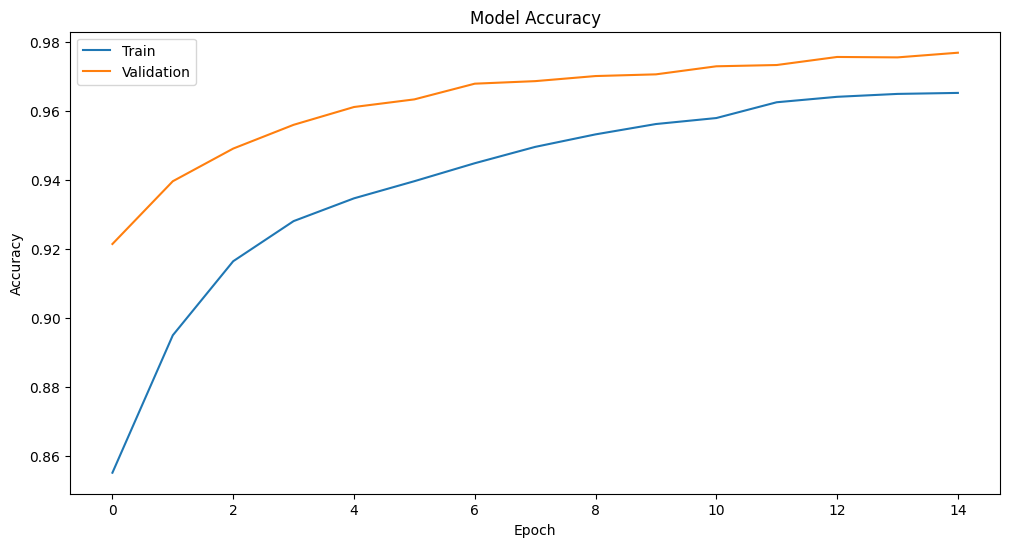

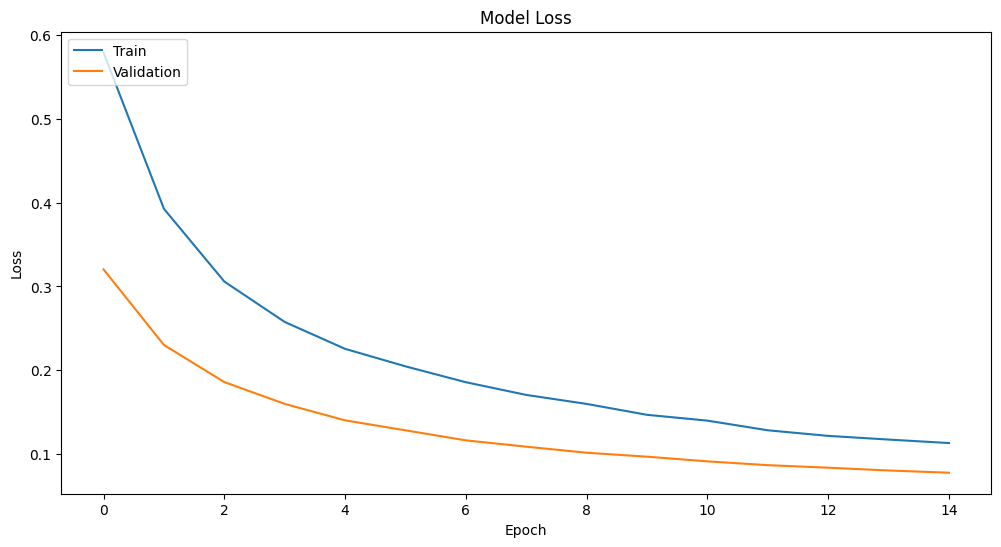

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Now, let's create a confusion matrix to evaluate the model's performance on the test data. This will help us understand which classes are being predicted correctly and which ones are being confused.

128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 357ms/step


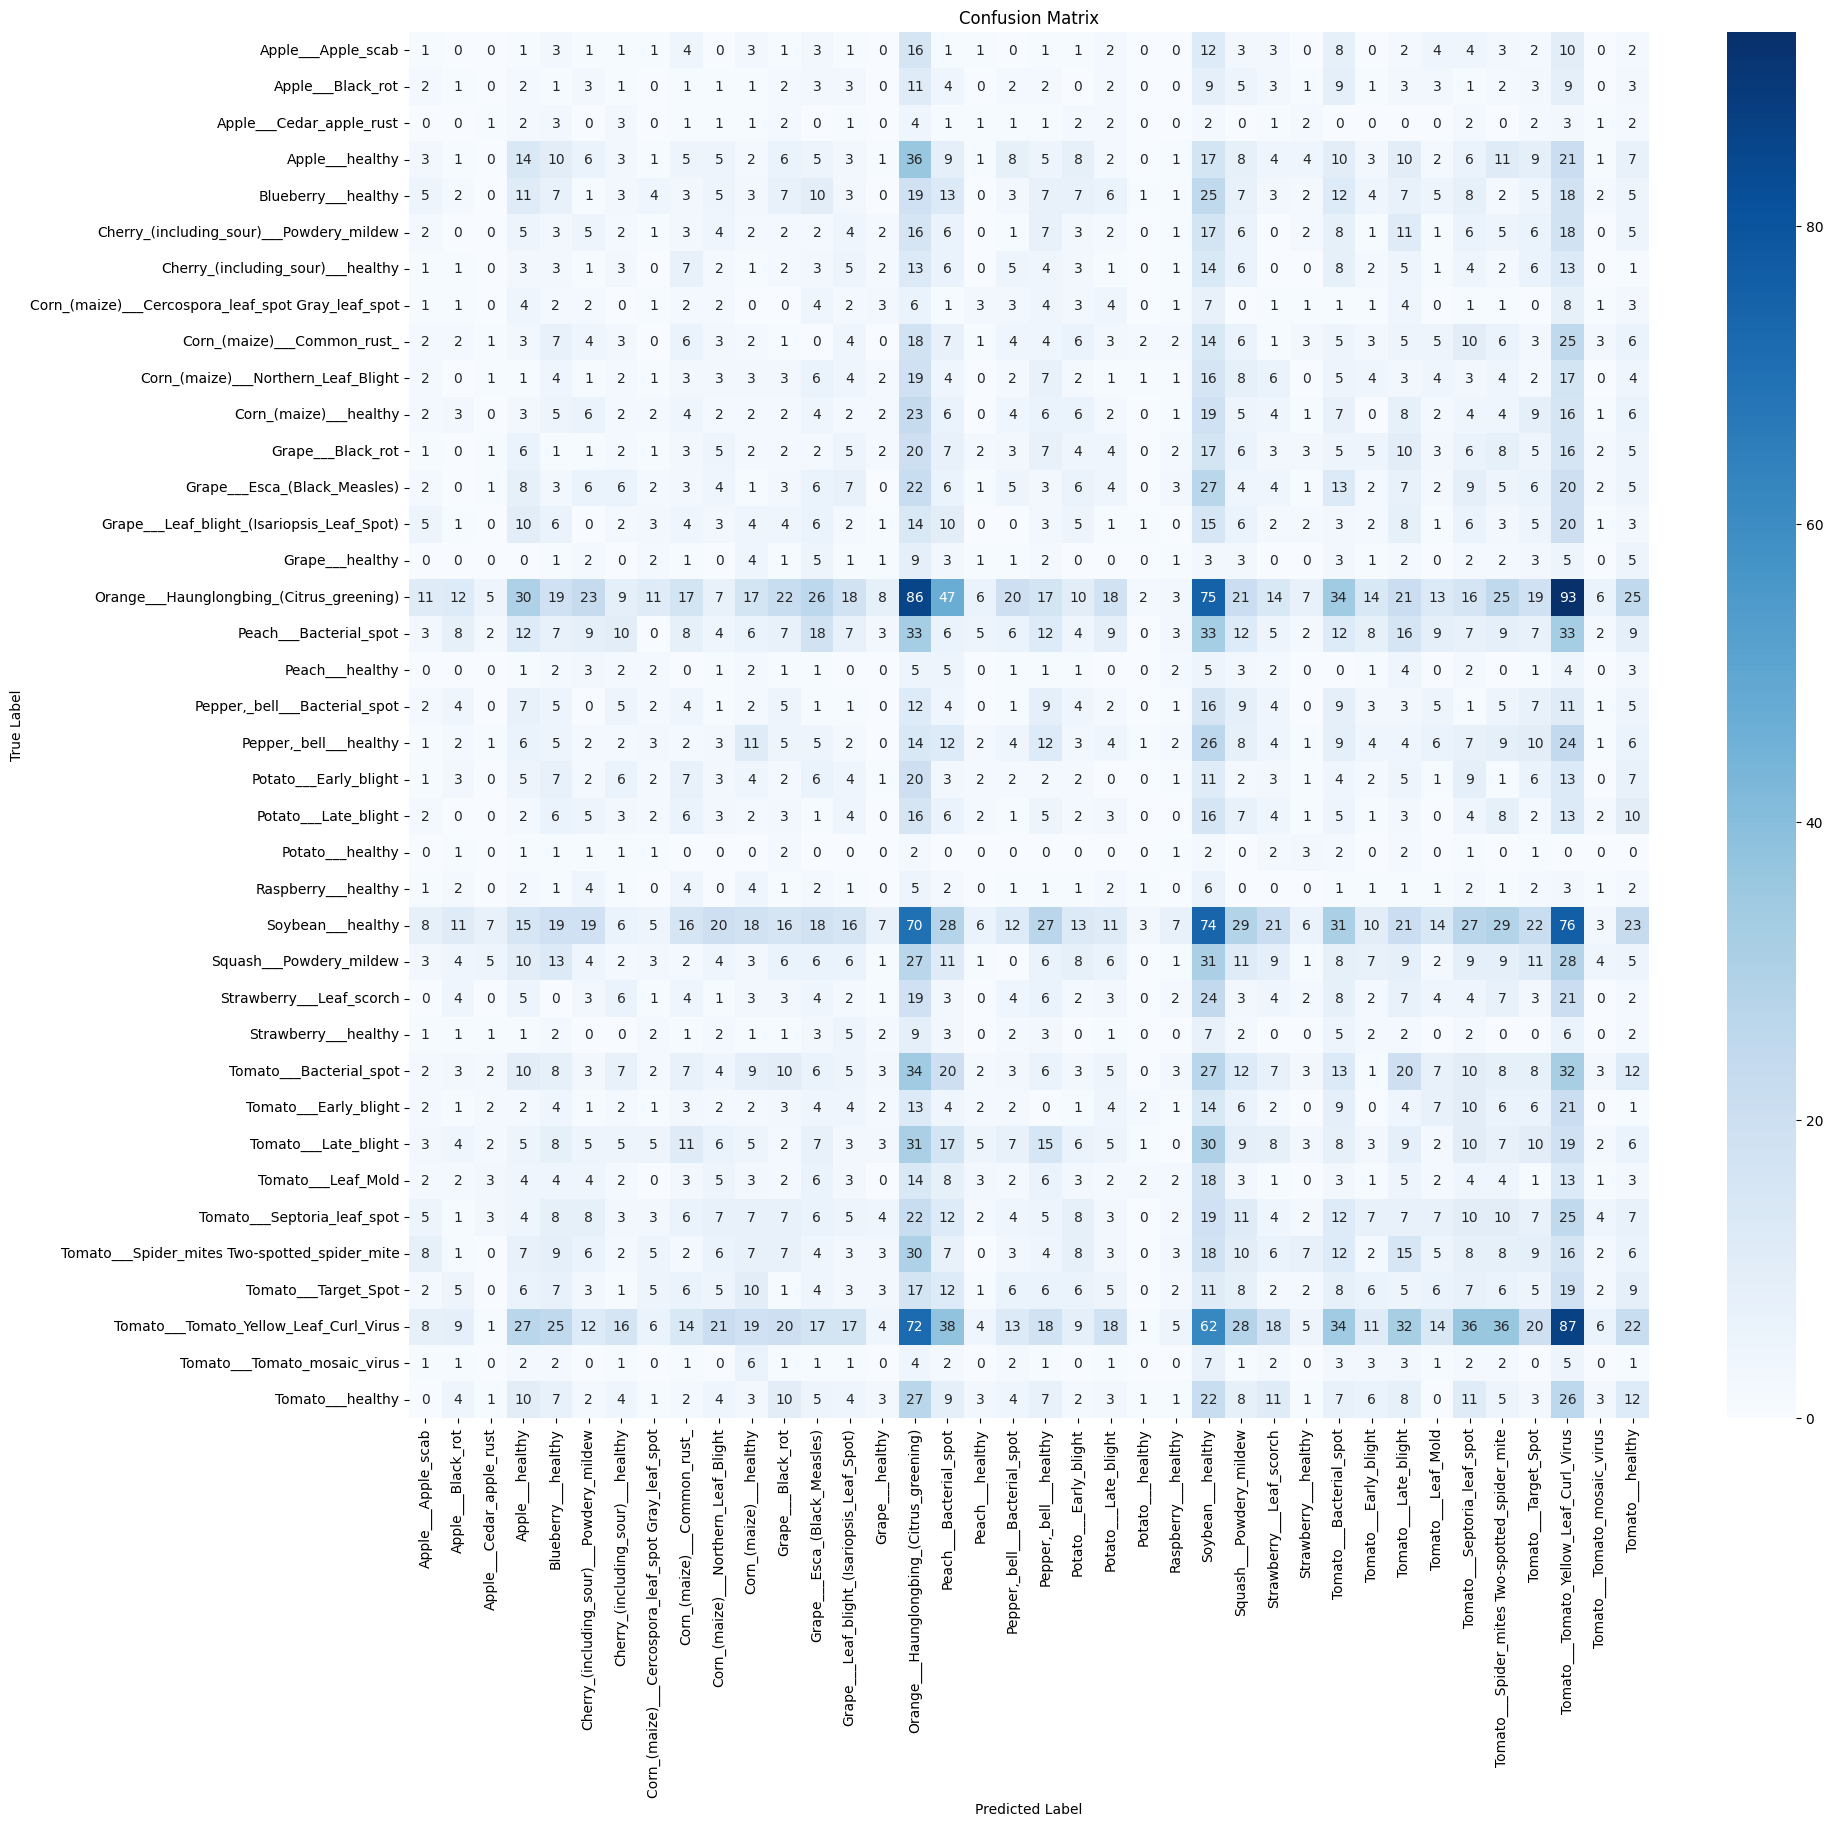

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.01      0.01      0.01        95
                                 Apple___Black_rot       0.01      0.01      0.01        94
                          Apple___Cedar_apple_rust       0.03      0.02      0.02        42
                                   Apple___healthy       0.06      0.06      0.06       248
                               Blueberry___healthy       0.03      0.03      0.03       226
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       159
                 Cherry_(including_sour)___healthy       0.02      0.02      0.02       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.01      0.01      0.01        78
                       Corn_(maize)___Common_rust_       0.03      0.03      0.03       180
               Corn_(maize)___Northern_Leaf_Blight       0.02      0.02      0.

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predicted labels for the test set
test_labels = test_generator.classes
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())

# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(test_labels, predicted_labels, target_names=class_names))

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.2
)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import os
import kagglehub
rabieoudghiri_plantvillage_split_70_15_15_path = kagglehub.dataset_download('rabieoudghiri/plantvillage-split-70-15-15')
base_data_path = rabieoudghiri_plantvillage_split_70_15_15_path
train_dir = os.path.join(base_data_path, 'plantvillage_split', 'train')
val_dir = os.path.join(base_data_path, 'plantvillage_split', 'valid')
test_dir = os.path.join(base_data_path, 'plantvillage_split', 'test')

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224,224), batch_size=64, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(224,224), batch_size=64, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224,224), batch_size=64, class_mode='categorical')

Using Colab cache for faster access to the 'plantvillage-split-70-15-15' dataset.
Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8180 images belonging to 38 classes.


In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)


model = Model(inputs=base_model.input, outputs=predictions)

from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=1e-3, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 97s 163ms/step - accuracy: 0.8552 - loss: 0.5791 - val_accuracy: 0.9215 - val_loss: 0.3203
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 90s 151ms/step - accuracy: 0.8950 - loss: 0.3927 - val_accuracy: 0.9397 - val_loss: 0.2301
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 89s 149ms/step - accuracy: 0.9165 - loss: 0.3058 - val_accuracy: 0.9492 - val_loss: 0.1858
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 91s 152ms/step - accuracy: 0.9282 - loss: 0.2576 - val_accuracy: 0.9561 - val_loss: 0.1597
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 89s 149ms/step - accuracy: 0.9348 - loss: 0.2255 - val_accuracy: 0.9612 - val_loss: 0.1401
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 88s 148ms/step - accuracy: 0.9397 - loss: 0.2046 - val_accuracy: 0.9635 - val_loss: 0.1282
Epoch 7/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 90s 151ms/step - accuracy: 0.9449 - loss: 0.1856 - val_accuracy: 0.9680 - val_loss: 0.1162
Epoch 8/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 90s 152ms/step - accuracy: 0.9497 - loss: 0

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
callbacks=[early_stop, checkpoint]

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 27s 211ms/step - accuracy: 0.9700 - loss: 0.0923
Test accuracy: 0.9691


In [ ]:
model.save('/content/plant_disease_efficientnetb0V2.h5')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save model to Google Drive
model.save('/content/drive/MyDrive/plant_disease_efficientnetb0V2.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
